In [ ]:
# Smart City Traffic Pattern Forecasting Using Machine Learning

## Internship Project

### Student Name: Your Name

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

### Machine Learning Algorithm
- Random Forest Regressor

In [1]:
import os

files = os.listdir()

print("Files in this folder:")
for file in files:
    print(file)

Files in this folder:
Project9_smart-city-traffic-patterns.docx
Smart_City_Traffic_Prediction.ipynb
.ipynb_checkpoints
datasets_8494_11879_test_BdBKkAj.csv
train_aWnotuB.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
train = pd.read_csv("train_aWnotuB.csv")
test = pd.read_csv("datasets_8494_11879_test_BdBKkAj.csv")

print("Train Dataset Shape:", train.shape)
print("Test Dataset Shape:", test.shape)

Train Dataset Shape: (48120, 4)
Test Dataset Shape: (11808, 3)


In [5]:
train.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [7]:
train.isnull().sum()

DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

In [8]:
train["DateTime"] = pd.to_datetime(train["DateTime"])

print(train.dtypes)

DateTime    datetime64[ns]
Junction             int64
Vehicles             int64
ID                   int64
dtype: object


In [9]:
train["Year"] = train["DateTime"].dt.year
train["Month"] = train["DateTime"].dt.month
train["Day"] = train["DateTime"].dt.day
train["Hour"] = train["DateTime"].dt.hour
train["DayOfWeek"] = train["DateTime"].dt.dayofweek

train.head()

,DateTime,Junction,Vehicles,ID,Year,Month,Day,Hour,DayOfWeek
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0,6
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1,6
2,2015-11-01 02:00:00,1,10,20151101021,2015,11,1,2,6
3,2015-11-01 03:00:00,1,7,20151101031,2015,11,1,3,6
4,2015-11-01 04:00:00,1,9,20151101041,2015,11,1,4,6


In [10]:
train.columns

Index(['DateTime', 'Junction', 'Vehicles', 'ID', 'Year', 'Month', 'Day',
       'Hour', 'DayOfWeek'],
      dtype='object')

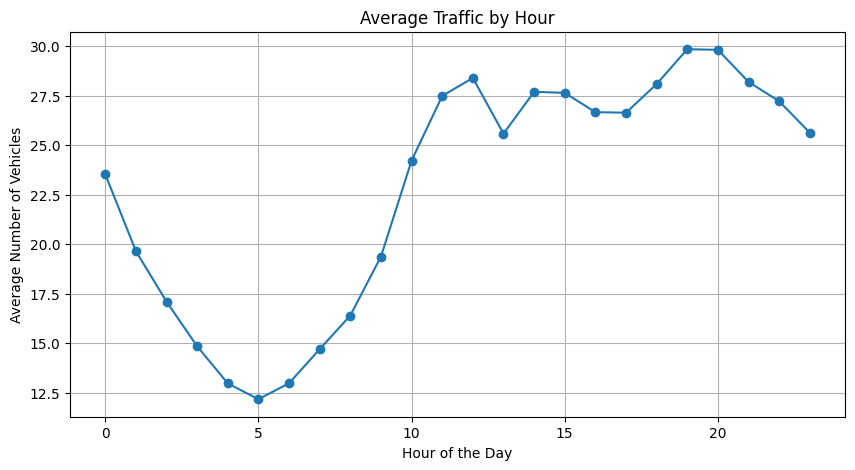

In [11]:
import matplotlib.pyplot as plt

hourly_traffic = train.groupby("Hour")["Vehicles"].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_traffic.index, hourly_traffic.values, marker='o')
plt.title("Average Traffic by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Average Number of Vehicles")
plt.grid(True)
plt.show()

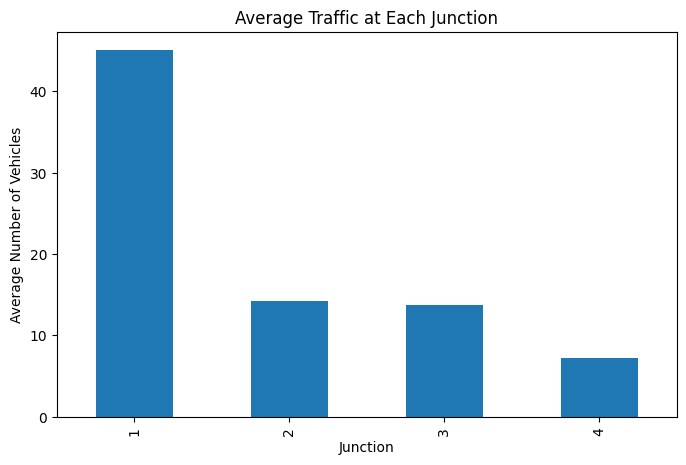

In [12]:
junction_traffic = train.groupby("Junction")["Vehicles"].mean()

plt.figure(figsize=(8,5))
junction_traffic.plot(kind="bar")
plt.title("Average Traffic at Each Junction")
plt.xlabel("Junction")
plt.ylabel("Average Number of Vehicles")
plt.show()

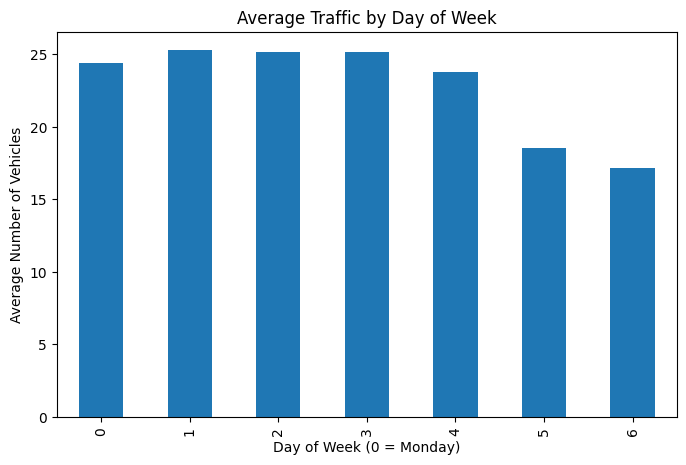

In [13]:
day_traffic = train.groupby("DayOfWeek")["Vehicles"].mean()

plt.figure(figsize=(8,5))
day_traffic.plot(kind="bar")
plt.title("Average Traffic by Day of Week")
plt.xlabel("Day of Week (0 = Monday)")
plt.ylabel("Average Number of Vehicles")
plt.show()

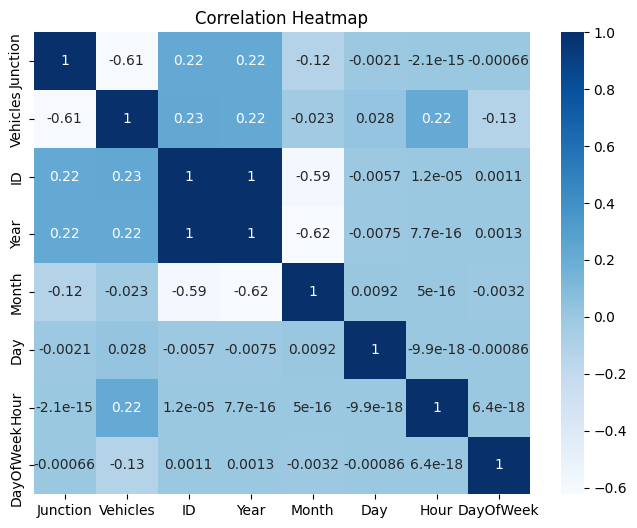

In [14]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

In [15]:
# Select input features
X = train[['Junction', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek']]

# Target variable
y = train['Vehicles']

print(X.head())
print("\nTarget:")
print(y.head())

   Junction  Year  Month  Day  Hour  DayOfWeek
0         1  2015     11    1     0          6
1         1  2015     11    1     1          6
2         1  2015     11    1     2          6
3         1  2015     11    1     3          6
4         1  2015     11    1     4          6

Target:
0    15
1    13
2    10
3     7
4     9
Name: Vehicles, dtype: int64


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (38496, 6)
Testing Data: (9624, 6)


In [18]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [19]:
y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[ 9.8  48.76  8.16 11.29 19.14  9.74 12.1  14.8  14.23 27.95]


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R² Score:", round(r2,4))

MAE : 2.4
RMSE: 3.56
R² Score: 0.969


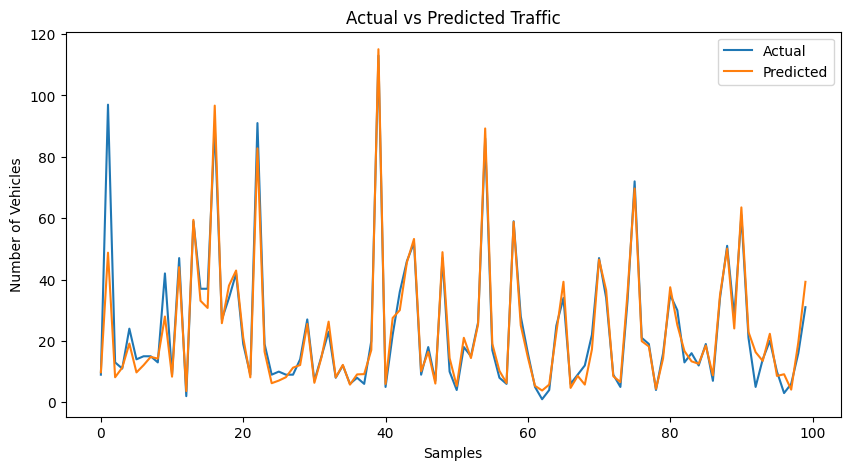

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")

plt.title("Actual vs Predicted Traffic")
plt.xlabel("Samples")
plt.ylabel("Number of Vehicles")
plt.legend()

plt.show()

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

print("Model Comparison")
print("-" * 40)

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    score = r2_score(y_test, pred)
    print(f"{name}: {score:.4f}")

Model Comparison
----------------------------------------
Linear Regression: 0.5997
Decision Tree: 0.9436
Random Forest: 0.9690


In [23]:
import joblib

joblib.dump(model, "traffic_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
# Conclusion

This project analyzes and forecasts smart city traffic using machine learning.

The dataset was preprocessed by converting the DateTime column and extracting useful features such as Year, Month, Day, Hour, and Day of Week.

Exploratory Data Analysis (EDA) was performed to understand traffic patterns across different hours, junctions, and days.

A Random Forest Regressor was trained to predict vehicle traffic. The model achieved good prediction performance and can help in traffic management and smart city planning.